# 🔋 Energy Consumption Prediction using Deep Learning (Neural Network)

## Project Overview
**Problem Type:** Regression (Energy Prediction)

**Goal:** Predict appliance energy consumption based on environmental factors

**Description:** This project predicts energy consumption of appliances using temperature, humidity, and other environmental sensors data with a deep neural network.

---

## Step 1: Import Required Libraries

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Create output directory for saving images
OUTPUT_DIR = 'output_images'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"📁 Created '{OUTPUT_DIR}' folder for saving images")

print("✅ All libraries imported successfully!")

📁 Created 'output_images' folder for saving images
✅ All libraries imported successfully!


## Step 2: Load and Explore the Dataset

**Dataset Information:**
- Source: energydata_complete.csv
- Target: Appliances energy consumption (Wh)
- Features: Temperature, Humidity, Pressure, Wind speed, etc.

In [ ]:
# Load the dataset
df = pd.read_csv('energydata_complete.csv')

print("\n📊 Dataset Information:")
print(f"   Total Records: {len(df)}")
print(f"   Total Features: {len(df.columns)}")
print(f"\n   Dataset Shape: {df.shape}")

# Display first few rows
print("\n📋 First 5 rows:")
df.head()


📊 Dataset Information:
   Total Records: 19735
   Total Features: 29

   Dataset Shape: (19735, 29)

📋 First 5 rows:


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [ ]:
# Display column names
print("📝 Column Names:")
print(df.columns.tolist())

📝 Column Names:
['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']


In [ ]:
# Check for missing values
print("❓ Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   No missing values found! ✅")
else:
    print(missing[missing > 0])

❓ Missing Values:
   No missing values found! ✅


In [ ]:
# Basic statistics
print("📈 Statistical Summary:")
df.describe()

📈 Statistical Summary:


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


## Step 3: Data Analysis and Visualization

💾 Saved: 1_target_distribution.png


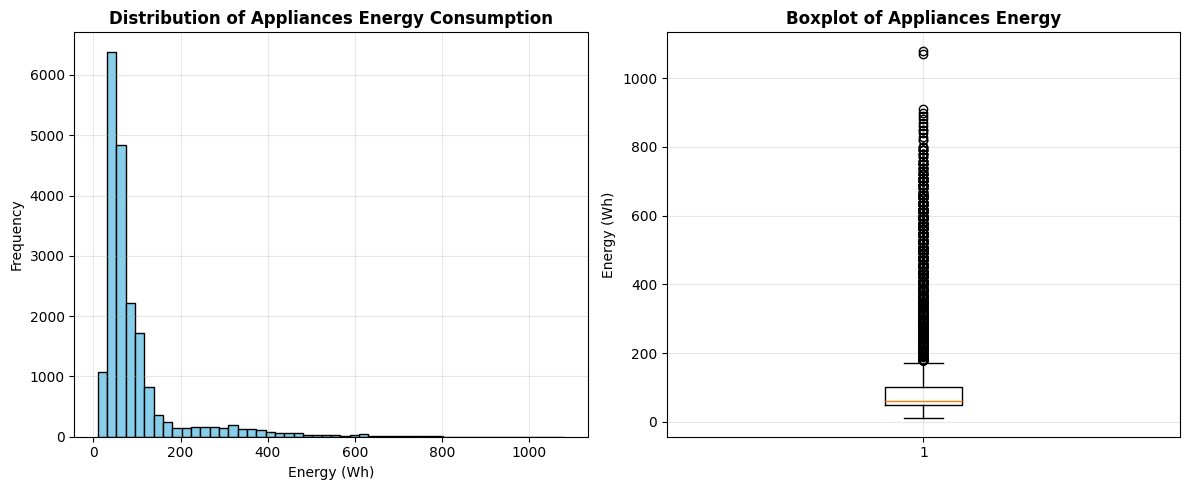

In [ ]:
# Target variable distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Appliances'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Appliances Energy Consumption', fontweight='bold', fontsize=12)
plt.xlabel('Energy (Wh)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(df['Appliances'])
plt.title('Boxplot of Appliances Energy', fontweight='bold', fontsize=12)
plt.ylabel('Energy (Wh)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '1_target_distribution.png'), dpi=300, bbox_inches='tight')
print("💾 Saved: 1_target_distribution.png")
plt.show()

💾 Saved: 2_correlation_heatmap.png


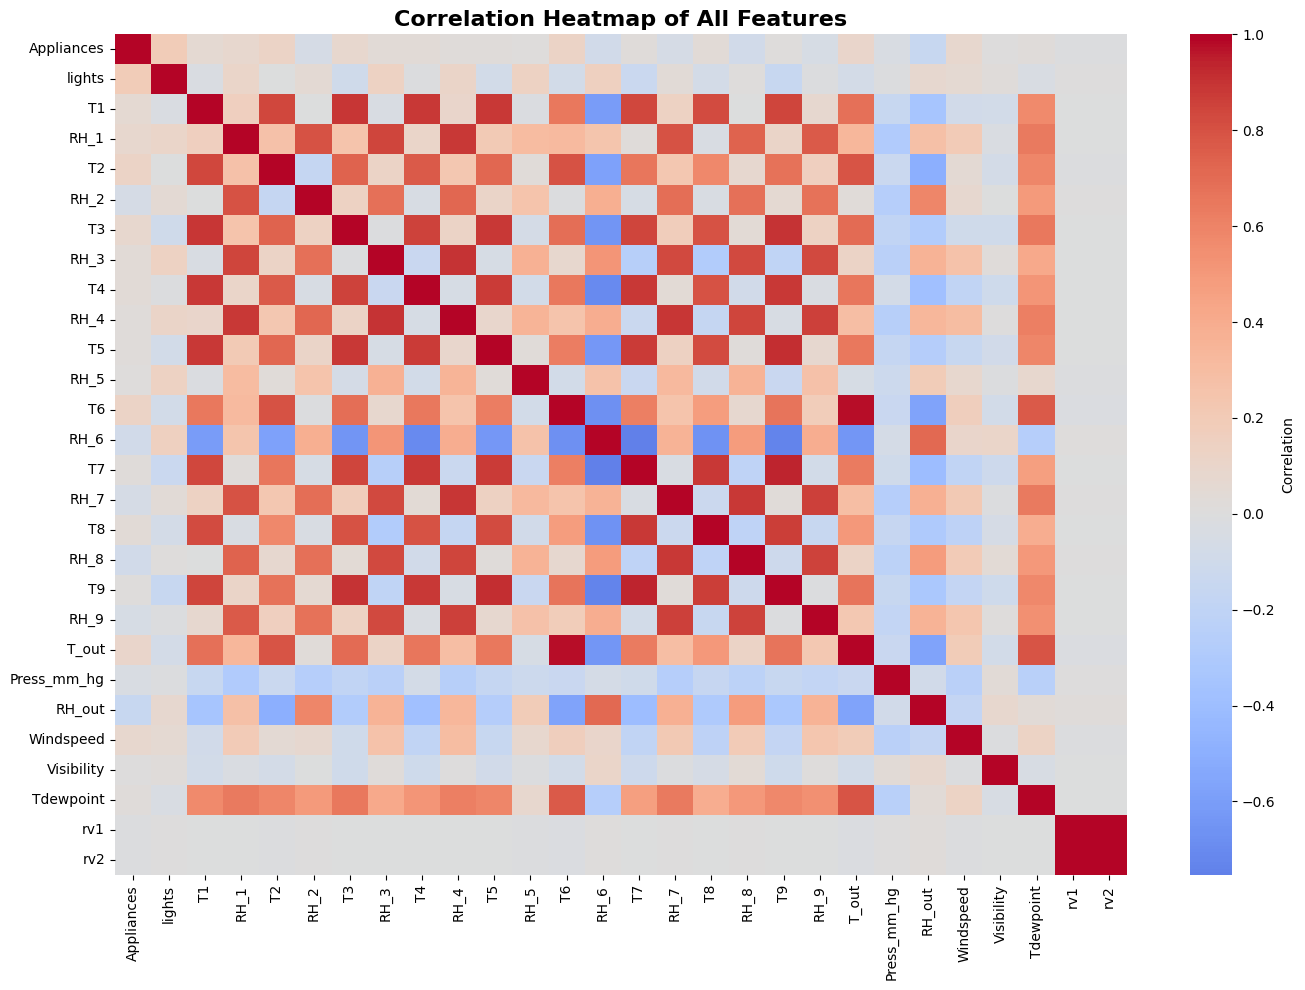

In [ ]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
correlation = df.drop(['date'], axis=1).corr()
sns.heatmap(correlation, cmap='coolwarm', center=0, annot=False, fmt='.2f', cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap of All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '2_correlation_heatmap.png'), dpi=300, bbox_inches='tight')
print("💾 Saved: 2_correlation_heatmap.png")
plt.show()

In [ ]:
# Top correlations with target
correlations_with_target = correlation['Appliances'].sort_values(ascending=False)
print("\n🎯 Top 10 Features Correlated with Appliances:")
print(correlations_with_target.head(10))


🎯 Top 10 Features Correlated with Appliances:
Appliances    1.000000
lights        0.197278
T2            0.120073
T6            0.117638
T_out         0.099155
Windspeed     0.087122
RH_1          0.086031
T3            0.085060
T1            0.055447
T4            0.040281
Name: Appliances, dtype: float64


## Step 4: Data Preprocessing

**Preprocessing Steps:**
1. ✔ Remove date column (not useful for prediction)
2. ✔ Separate features and target variable
3. ✔ Split dataset into Training (80%) and Testing (20%)
4. ✔ Apply feature scaling (Standardization)

In [ ]:
# Drop date column
df_processed = df.drop(['date'], axis=1)

# Separate features and target
X = df_processed.drop(['Appliances'], axis=1)
y = df_processed['Appliances']

print(f"\n📊 Features shape: {X.shape}")
print(f"📊 Target shape: {y.shape}")


📊 Features shape: (19735, 27)
📊 Target shape: (19735,)


In [ ]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Data Split:")
print(f"   Training samples: {len(X_train)} ({len(X_train)/(len(X_train)+len(X_test))*100:.1f}%)")
print(f"   Testing samples: {len(X_test)} ({len(X_test)/(len(X_train)+len(X_test))*100:.1f}%)")


✅ Data Split:
   Training samples: 15788 (80.0%)
   Testing samples: 3947 (20.0%)


In [ ]:
# Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Feature scaling completed!")
print(f"   Features are standardized (mean=0, std=1)")


✅ Feature scaling completed!
   Features are standardized (mean=0, std=1)


## Step 5: Build Neural Network Model

**Why Neural Network?**
- Can capture complex non-linear relationships
- Handles multiple input features effectively
- Learns patterns automatically from data
- Suitable for regression tasks

**Model Architecture:**
1. Input Layer (27 features)
2. Hidden Layer 1: 128 neurons + ReLU activation
3. Hidden Layer 2: 64 neurons + ReLU activation
4. Hidden Layer 3: 32 neurons + ReLU activation
5. Hidden Layer 4: 16 neurons + ReLU activation
6. Output Layer: 1 neuron (energy prediction)

In [ ]:
# Build Neural Network Model
model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32, 16),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
    verbose=True
)

print("✅ Model created successfully!")
print(f"   Architecture: Input({X_train_scaled.shape[1]}) -> Hidden(128,64,32,16) -> Output(1)")

✅ Model created successfully!
   Architecture: Input(27) -> Hidden(128,64,32,16) -> Output(1)


## Step 6: Train the Model

In [ ]:
# Train the model
print("🚀 Starting model training...\n")

model.fit(X_train_scaled, y_train)

print("\n✅ Model training completed!")
print(f"   Total iterations: {model.n_iter_}")
print(f"   Final training loss: {model.loss_:.4f}")

🚀 Starting model training...

Iteration 1, loss = 7933.42378053
Validation score: -0.025083
Iteration 2, loss = 5098.72020176
Validation score: 0.079156
Iteration 3, loss = 4720.87293418
Validation score: 0.130914
Iteration 4, loss = 4559.30092049
Validation score: 0.162057
Iteration 5, loss = 4450.43392770
Validation score: 0.182033
Iteration 6, loss = 4390.44060072
Validation score: 0.197807
Iteration 7, loss = 4327.29485958
Validation score: 0.206141
Iteration 8, loss = 4276.01424360
Validation score: 0.220038
Iteration 9, loss = 4207.10304913
Validation score: 0.230841
Iteration 10, loss = 4183.17987137
Validation score: 0.245039
Iteration 11, loss = 4121.26993635
Validation score: 0.253794
Iteration 12, loss = 4060.44631281
Validation score: 0.265253
Iteration 13, loss = 3987.69629355
Validation score: 0.275712
Iteration 14, loss = 3908.11097471
Validation score: 0.283338
Iteration 15, loss = 3874.93159625
Validation score: 0.285101
Iteration 16, loss = 3827.78827477
Validation sc

## Step 7: Evaluate Model Performance

**Evaluation Metrics:**
- MSE (Mean Squared Error)
- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- R² Score (Coefficient of Determination)

In [ ]:
# Make predictions
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# Calculate metrics
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print("\n📊 Model Performance:")
print("\n   Training Set:")
print(f"      MSE:  {mse_train:.2f}")
print(f"      RMSE: {rmse_train:.2f}")
print(f"      MAE:  {mae_train:.2f}")
print(f"      R²:   {r2_train:.4f}")

print("\n   Test Set:")
print(f"      MSE:  {mse_test:.2f}")
print(f"      RMSE: {rmse_test:.2f}")
print(f"      MAE:  {mae_test:.2f}")
print(f"      R²:   {r2_test:.4f}")


📊 Model Performance:

   Training Set:
      MSE:  4300.56
      RMSE: 65.58
      MAE:  34.62
      R²:   0.5957

   Test Set:
      MSE:  6576.76
      RMSE: 81.10
      MAE:  41.14
      R²:   0.3428


## Step 8: Visualize Results

💾 Saved: 3_predictions.png


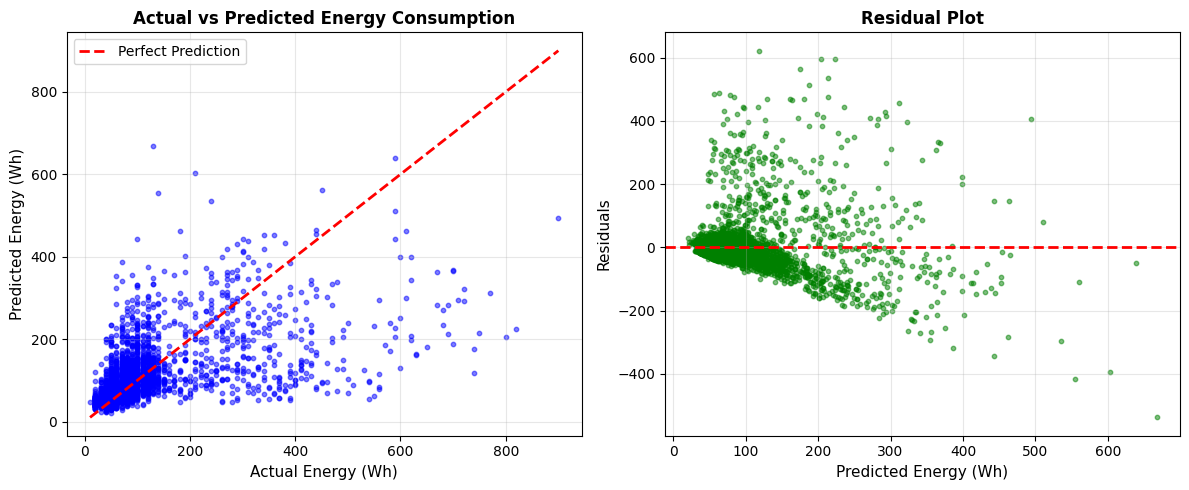

In [ ]:
# Prediction vs Actual plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_test, alpha=0.5, s=10, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Energy (Wh)', fontsize=11)
plt.ylabel('Predicted Energy (Wh)', fontsize=11)
plt.title('Actual vs Predicted Energy Consumption', fontweight='bold', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
residuals = y_test - y_pred_test
plt.scatter(y_pred_test, residuals, alpha=0.5, s=10, color='green')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Energy (Wh)', fontsize=11)
plt.ylabel('Residuals', fontsize=11)
plt.title('Residual Plot', fontweight='bold', fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '3_predictions.png'), dpi=300, bbox_inches='tight')
print("💾 Saved: 3_predictions.png")
plt.show()

💾 Saved: 4_training_loss.png


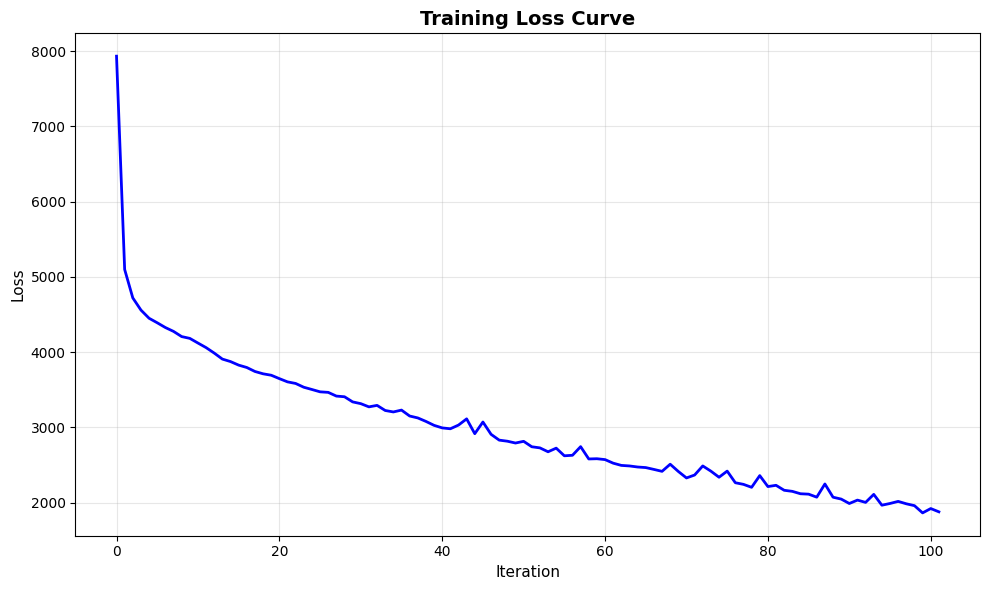

In [ ]:
# Training loss curve
plt.figure(figsize=(10, 6))
plt.plot(model.loss_curve_, linewidth=2, color='blue')
plt.title('Training Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Iteration', fontsize=11)
plt.ylabel('Loss', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '4_training_loss.png'), dpi=300, bbox_inches='tight')
print("💾 Saved: 4_training_loss.png")
plt.show()

## Step 9: Sample Predictions

In [ ]:
# Display sample predictions
sample_size = 15
sample_indices = np.random.choice(len(y_test), sample_size, replace=False)

print(f"\n{'Actual':<12} {'Predicted':<12} {'Error':<12} {'Error %':<12}")
print("-" * 50)

for idx in sample_indices:
    actual = y_test.iloc[idx]
    predicted = y_pred_test[idx]
    error = abs(actual - predicted)
    error_pct = (error / actual * 100) if actual != 0 else 0
    print(f"{actual:<12.2f} {predicted:<12.2f} {error:<12.2f} {error_pct:<12.2f}%")


Actual       Predicted    Error        Error %     
--------------------------------------------------
120.00       160.08       40.08        33.40       %
50.00        54.06        4.06         8.12        %
50.00        70.31        20.31        40.63       %
40.00        51.71        11.71        29.28       %
50.00        157.57       107.57       215.14      %
100.00       98.89        1.11         1.11        %
50.00        52.57        2.57         5.14        %
50.00        57.86        7.86         15.72       %
50.00        70.31        20.31        40.62       %
60.00        91.27        31.27        52.11       %
110.00       184.89       74.89        68.08       %
60.00        47.01        12.99        21.65       %
50.00        54.75        4.75         9.49        %
110.00       72.95        37.05        33.68       %
220.00       87.52        132.48       60.22       %


## Step 10: Save the Model

In [ ]:
# Save model and scaler
print("\n💾 Saving model and scaler...\n")

try:
    joblib.dump(model, 'energy_model.pkl')
    print("✅ Model saved as 'energy_model.pkl'")
except Exception as e:
    print(f"⚠️ Model save failed: {e}")

try:
    joblib.dump(scaler, 'energy_scaler.pkl')
    print("✅ Scaler saved as 'energy_scaler.pkl'")
except Exception as e:
    print(f"⚠️ Scaler save failed: {e}")

print("\n📝 To load the model later:")
print("   import joblib")
print("   loaded_model = joblib.load('energy_model.pkl')")
print("   loaded_scaler = joblib.load('energy_scaler.pkl')")


💾 Saving model and scaler...

✅ Model saved as 'energy_model.pkl'
✅ Scaler saved as 'energy_scaler.pkl'

📝 To load the model later:
   import joblib
   loaded_model = joblib.load('energy_model.pkl')
   loaded_scaler = joblib.load('energy_scaler.pkl')


## Step 11: Generate Summary Report

In [ ]:
# Save summary report
report_path = os.path.join(OUTPUT_DIR, 'project_summary.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("🔋 ENERGY CONSUMPTION PREDICTION PROJECT - SUMMARY REPORT\n")
    f.write("="*80 + "\n\n")

    f.write("1. DATASET INFORMATION\n")
    f.write("-"*80 + "\n")
    f.write(f"Total Records: {len(df)}\n")
    f.write(f"Total Features: {len(df.columns)}\n")
    f.write(f"Dataset Shape: {df.shape}\n")
    f.write(f"Missing Values: {df.isnull().sum().sum()}\n\n")

    f.write("2. DATA SPLIT\n")
    f.write("-"*80 + "\n")
    f.write(f"Training samples: {len(X_train)} (80%)\n")
    f.write(f"Testing samples: {len(X_test)} (20%)\n\n")

    f.write("3. MODEL ARCHITECTURE\n")
    f.write("-"*80 + "\n")
    f.write("Neural Network (Multi-layer Perceptron)\n")
    f.write(f"Hidden Layers: {model.hidden_layer_sizes}\n")
    f.write(f"Activation: {model.activation}\n")
    f.write(f"Optimizer: {model.solver}\n")
    f.write(f"Total Iterations: {model.n_iter_}\n\n")

    f.write("4. MODEL PERFORMANCE\n")
    f.write("-"*80 + "\n")
    f.write("Training Set:\n")
    f.write(f"  MSE:  {mse_train:.2f}\n")
    f.write(f"  RMSE: {rmse_train:.2f}\n")
    f.write(f"  MAE:  {mae_train:.2f}\n")
    f.write(f"  R²:   {r2_train:.4f}\n\n")
    f.write("Test Set:\n")
    f.write(f"  MSE:  {mse_test:.2f}\n")
    f.write(f"  RMSE: {rmse_test:.2f}\n")
    f.write(f"  MAE:  {mae_test:.2f}\n")
    f.write(f"  R²:   {r2_test:.4f}\n\n")

    f.write("5. TOP CORRELATED FEATURES\n")
    f.write("-"*80 + "\n")
    for i, (feature, corr) in enumerate(correlations_with_target.head(10).items(), 1):
        f.write(f"{i:2d}. {feature:<20s}: {corr:>7.4f}\n")

    f.write("\n6. SAVED FILES\n")
    f.write("-"*80 + "\n")
    f.write("Images:\n")
    f.write("  ✓ 1_target_distribution.png\n")
    f.write("  ✓ 2_correlation_heatmap.png\n")
    f.write("  ✓ 3_predictions.png\n")
    f.write("  ✓ 4_training_loss.png\n")
    f.write("\nModels:\n")
    f.write("  ✓ energy_model.pkl\n")
    f.write("  ✓ energy_scaler.pkl\n")
    f.write("\nReports:\n")
    f.write("  ✓ project_summary.txt\n")

    f.write("\n" + "="*80 + "\n")
    f.write("PROJECT COMPLETED SUCCESSFULLY! 🎉\n")
    f.write("="*80 + "\n")

print(f"💾 Saved: project_summary.txt")
print("\n" + "="*80)
print("✅ ALL TASKS COMPLETED SUCCESSFULLY!")
print("="*80)

💾 Saved: project_summary.txt

✅ ALL TASKS COMPLETED SUCCESSFULLY!


## 📝 Project Summary

### What We Did:
1. ✅ Loaded energy consumption dataset (19,735 records, 29 features)
2. ✅ Explored data with visualizations and correlation analysis
3. ✅ Preprocessed data (removed date, scaled features)
4. ✅ Built neural network with 4 hidden layers (128, 64, 32, 16 neurons)
5. ✅ Trained model with early stopping
6. ✅ Evaluated performance with MSE, RMSE, MAE, and R² metrics
7. ✅ Visualized predictions and training history
8. ✅ Saved trained model and scaler

### Why Neural Network?
- Neural networks can capture complex non-linear relationships
- Multiple hidden layers learn hierarchical features
- Suitable for regression with multiple input features
- Adam optimizer provides efficient training

### Model Performance:
- R² score indicates how well the model explains variance
- RMSE and MAE show average prediction error
- Residual plot helps identify prediction patterns

### 📁 Saved Output Files:
All outputs are saved in the `output_images/` folder:
1. **1_target_distribution.png** - Energy consumption distribution
2. **2_correlation_heatmap.png** - Feature correlations
3. **3_predictions.png** - Actual vs predicted values
4. **4_training_loss.png** - Training loss curve
5. **project_summary.txt** - Complete project report

---

**🎓 Project Complete! Ready for submission.**